# Training Results Visualization

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from adjustText import adjust_text

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

# Experiment Configuration

Specify the training-test combination you want to analyze
- Available training datasets: alpaca, dolly, flan_v2, cot, oasst1, vicuna, wizardlm, openhermes, tulu3
- Available tasks: tydiqa, samsum, gsm8k, math500, mmlu (with subject)

## Method Definitions

Each method is defined by 6 components:
1. **Data Selection**: `NA` (none) or `GREATS` (gradient-based selection)
2. **Optimizer**: `Regular` (standard AdamW) or `MeSO` (memory-efficient second-order)
3. **Compression**: `NA`, `GraSS` (gradient sparse sketch), or `LoGra` (low-rank gradient)
4. **Training Type**: `full` (full fine-tuning) or `lora` (LoRA fine-tuning)
5. **Selection Mode**: `global` (default) or `per_layer` - controls how data selection is performed with MeSO
6. **Second-Order**: `False` or `True` - enables greedy selection with second-order interactions

## Available Configurations (16 total)

| Category | Methods |
|----------|---------|
| Baselines | Regular, LoRA |
| GREATS Data Selection | GREATS (GraSS/LoGra), GREATS+LoRA (GraSS/LoGra) |
| MeSO Optimizer | MeSO (GraSS/LoGra) |
| MeSO + GREATS (Global Selection) | MeSO+GREATS (GraSS/LoGra) |
| MeSO + GREATS Per-layer | MeSO+GREATS Per-layer (GraSS/LoGra) |
| MeSO + GREATS + Second-Order (Global) | MeSO+GREATS+2nd (GraSS/LoGra) |
| MeSO + GREATS Per-layer + Second-Order | MeSO+GREATS Per-layer+2nd (GraSS/LoGra) |

In [44]:
model = 'llama3-1b'
train_dataset = 'wizardlm'
task = 'samsum'
subject = None # Only needed for mmlu/bbh tasks (e.g., 'sociology', 'abstract_algebra')
out_dir = "/scratch/pbb/Project/Efficient-Fine-Tuning"

default_config = {
    'batch_size': 8,
    'percentage': 0.2,
    'n_val': 8,
    'lr_full': '5e-06',      # Learning rate for full fine-tuning
    'lr_lora': '1e-04',      # Learning rate for LoRA fine-tuning
    'seed': 42,
}

# ============================================
# Plot Filtering Options
# ============================================
show_second_order = True      # Set to True to include +2nd methods
show_per_layer = True          # Set to True to include Per-layer selection methods
show_lora = True               # Set to True to include LoRA methods

In [45]:
# Each method is defined by: (data_selection, optimizer, compression, training_type, selection_mode, use_second_order)
# - data_selection: 'NA' or 'GREATS'
# - optimizer: 'Regular' or 'MeSO'
# - compression: 'NA', 'GraSS', or 'LoGra'
# - training_type: 'full' or 'lora'
# - selection_mode: 'global' (default) or 'per_layer' - only applies to MeSO+GREATS
# - use_second_order: False (default) or True - greedy selection with second-order interactions

method_definitions = {
    # ============================================
    # Baselines (no compression, no data selection)
    # ============================================
    'Regular': ('NA', 'Regular', 'NA', 'full', 'global', False),
    'LoRA': ('NA', 'Regular', 'NA', 'lora', 'global', False),

    # ============================================
    # GREATS Data Selection (no MeSO optimizer)
    # Uses global selection by default (accumulates scores across all layers)
    # ============================================
    'GREATS (GraSS)': ('GREATS', 'Regular', 'GraSS', 'full', 'global', False),
    'GREATS (LoGra)': ('GREATS', 'Regular', 'LoGra', 'full', 'global', False),
    'GREATS+LoRA (GraSS)': ('GREATS', 'Regular', 'GraSS', 'lora', 'global', False),
    'GREATS+LoRA (LoGra)': ('GREATS', 'Regular', 'LoGra', 'lora', 'global', False),

    # ============================================
    # MeSO Compressed Optimizer (no data selection)
    # ============================================
    'MeSO (GraSS)': ('NA', 'MeSO', 'GraSS', 'full', 'global', False),
    'MeSO (LoGra)': ('NA', 'MeSO', 'LoGra', 'full', 'global', False),

    # ============================================
    # MeSO + GREATS with Global Selection (default)
    # Accumulates scores across all layers, then selects globally
    # ============================================
    'MeSO+GREATS (GraSS)': ('GREATS', 'MeSO', 'GraSS', 'full', 'global', False),
    'MeSO+GREATS (LoGra)': ('GREATS', 'MeSO', 'LoGra', 'full', 'global', False),

    # ============================================
    # MeSO + GREATS with Per-layer Selection
    # Each layer independently selects samples (block-diagonal approximation)
    # ============================================
    'MeSO+GREATS Per-layer (GraSS)': ('GREATS', 'MeSO', 'GraSS', 'full', 'per_layer', False),
    'MeSO+GREATS Per-layer (LoGra)': ('GREATS', 'MeSO', 'LoGra', 'full', 'per_layer', False),

    # ============================================
    # MeSO + GREATS with Second-Order (Global)
    # ============================================
    'MeSO+GREATS+2nd (GraSS)': ('GREATS', 'MeSO', 'GraSS', 'full', 'global', True),
    'MeSO+GREATS+2nd (LoGra)': ('GREATS', 'MeSO', 'LoGra', 'full', 'global', True),

    # ============================================
    # MeSO + GREATS with Per-layer Selection + Second-Order
    # ============================================
    'MeSO+GREATS Per-layer+2nd (GraSS)': ('GREATS', 'MeSO', 'GraSS', 'full', 'per_layer', True),
    'MeSO+GREATS Per-layer+2nd (LoGra)': ('GREATS', 'MeSO', 'LoGra', 'full', 'per_layer', True),
}

# Filter methods based on options
def should_include_method(name, definition):
    """Check if a method should be included based on filter settings."""
    data_selection, optimizer, compression, training_type, selection_mode, use_second_order = definition

    # Filter second-order methods
    if not show_second_order and use_second_order:
        return False

    # Filter per-layer selection methods (only for MeSO+GREATS)
    if not show_per_layer and optimizer == 'MeSO' and data_selection != 'NA' and selection_mode == 'per_layer':
        return False

    # Filter LoRA methods
    if not show_lora and training_type == 'lora':
        return False

    return True

# Apply filters
filtered_methods = {name: defn for name, defn in method_definitions.items()
                    if should_include_method(name, defn)}

print(f"Showing {len(filtered_methods)}/{len(method_definitions)} methods:")
for name in filtered_methods:
    print(f"  - {name}")

Showing 16/16 methods:
  - Regular
  - LoRA
  - GREATS (GraSS)
  - GREATS (LoGra)
  - GREATS+LoRA (GraSS)
  - GREATS+LoRA (LoGra)
  - MeSO (GraSS)
  - MeSO (LoGra)
  - MeSO+GREATS (GraSS)
  - MeSO+GREATS (LoGra)
  - MeSO+GREATS Per-layer (GraSS)
  - MeSO+GREATS Per-layer (LoGra)
  - MeSO+GREATS+2nd (GraSS)
  - MeSO+GREATS+2nd (LoGra)
  - MeSO+GREATS Per-layer+2nd (GraSS)
  - MeSO+GREATS Per-layer+2nd (LoGra)


## Load Results

In [46]:
def load_results(result_path):
    """Load evaluation results from JSON file."""
    with open(result_path, 'r') as f:
        data = json.load(f)

    steps = [item['step'] for item in data]
    val_perplexity = [item['val_perplexity'] for item in data]
    eval_perplexity = [item['eval_perplexity'] for item in data]
    wall_time = [item.get('wall_time', None) for item in data]

    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_perplexity),
        'eval_perplexity': np.array(eval_perplexity),
        'wall_time': np.array(wall_time) if all(t is not None for t in wall_time) else None,
    }


def build_experiment_path(train_dataset, task, method_name, config=None, subject=None):
    """
    Build the experiment directory path based on the naming convention.

    Directory format:
    {train_dataset}_{task}-{method_str}-{model}-{job_type}-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}

    Where method_str is: {data_selection}-{optimizer}-{compression}[-per_layer][-2nd]
    - '-per_layer' suffix is added for MeSO+GREATS with per-layer selection mode
    - '-2nd' suffix is added for data selection with second-order interactions
    """
    if method_name not in method_definitions:
        return None

    # Get method definition (now 6 elements)
    data_selection, optimizer, compression, training_type, selection_mode, use_second_order = method_definitions[method_name]

    # Use default config or provided config
    cfg = config or default_config
    batch_size = cfg['batch_size']
    percentage = cfg['percentage']
    n_val = cfg['n_val']
    seed = cfg['seed']
    lr = cfg['lr_lora'] if training_type == 'lora' else cfg['lr_full']

    # Build method string: data_selection-optimizer-compression[-per_layer][-2nd]
    method_str = f"{data_selection}-{optimizer}-{compression}"

    # Add '-per_layer' suffix for MeSO+GREATS with per-layer selection mode
    if optimizer == 'MeSO' and data_selection != 'NA' and selection_mode == 'per_layer':
        method_str = f"{method_str}-per_layer"

    # Add '-2nd' suffix for data selection with second-order interactions
    if data_selection != 'NA' and use_second_order:
        method_str = f"{method_str}-2nd"

    # Build setting string: model-job_type-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}
    setting_str = f"{model}-{training_type}-p{percentage}-lr{lr}-b{batch_size}-v{n_val}-s{seed}"

    # Build task string (with subject for MMLU/BBH)
    if task in ['mmlu', 'bbh'] and subject:
        task_str = f"{task}_{subject}"
    else:
        task_str = task

    # Full directory name
    dir_name = f"{train_dataset}_{task_str}-{method_str}-{setting_str}"

    return f"{out_dir}/{dir_name}/evaluation_results.json"


# Build experiment paths for FILTERED methods only
experiments = {}
for method_name in filtered_methods.keys():
    path = build_experiment_path(train_dataset, task, method_name, default_config, subject)
    if path:
        experiments[method_name] = path

# Load all results
results = {}
print(f"Loading results for: {train_dataset} → {task}")
print("=" * 60)

for name, path in experiments.items():
    if Path(path).exists():
        results[name] = load_results(path)
        print(f"✓ {name}: {len(results[name]['steps'])} evaluation points")
    else:
        print(f"✗ {name}: Not found")
        # Print expected path for debugging
        # print(f"  Expected: {path}")

print("=" * 60)
print(f"Loaded {len(results)}/{len(experiments)} experiments")

Loading results for: wizardlm → samsum
✓ Regular: 36 evaluation points
✓ LoRA: 36 evaluation points
✓ GREATS (GraSS): 36 evaluation points
✓ GREATS (LoGra): 36 evaluation points
✓ GREATS+LoRA (GraSS): 36 evaluation points
✓ GREATS+LoRA (LoGra): 36 evaluation points
✓ MeSO (GraSS): 30 evaluation points
✓ MeSO (LoGra): 36 evaluation points
✓ MeSO+GREATS (GraSS): 36 evaluation points
✓ MeSO+GREATS (LoGra): 36 evaluation points
✓ MeSO+GREATS Per-layer (GraSS): 36 evaluation points
✓ MeSO+GREATS Per-layer (LoGra): 36 evaluation points
✓ MeSO+GREATS+2nd (GraSS): 36 evaluation points
✓ MeSO+GREATS+2nd (LoGra): 36 evaluation points
✓ MeSO+GREATS Per-layer+2nd (GraSS): 36 evaluation points
✓ MeSO+GREATS Per-layer+2nd (LoGra): 36 evaluation points
Loaded 16/16 experiments


## Plot Perplexity Over Training

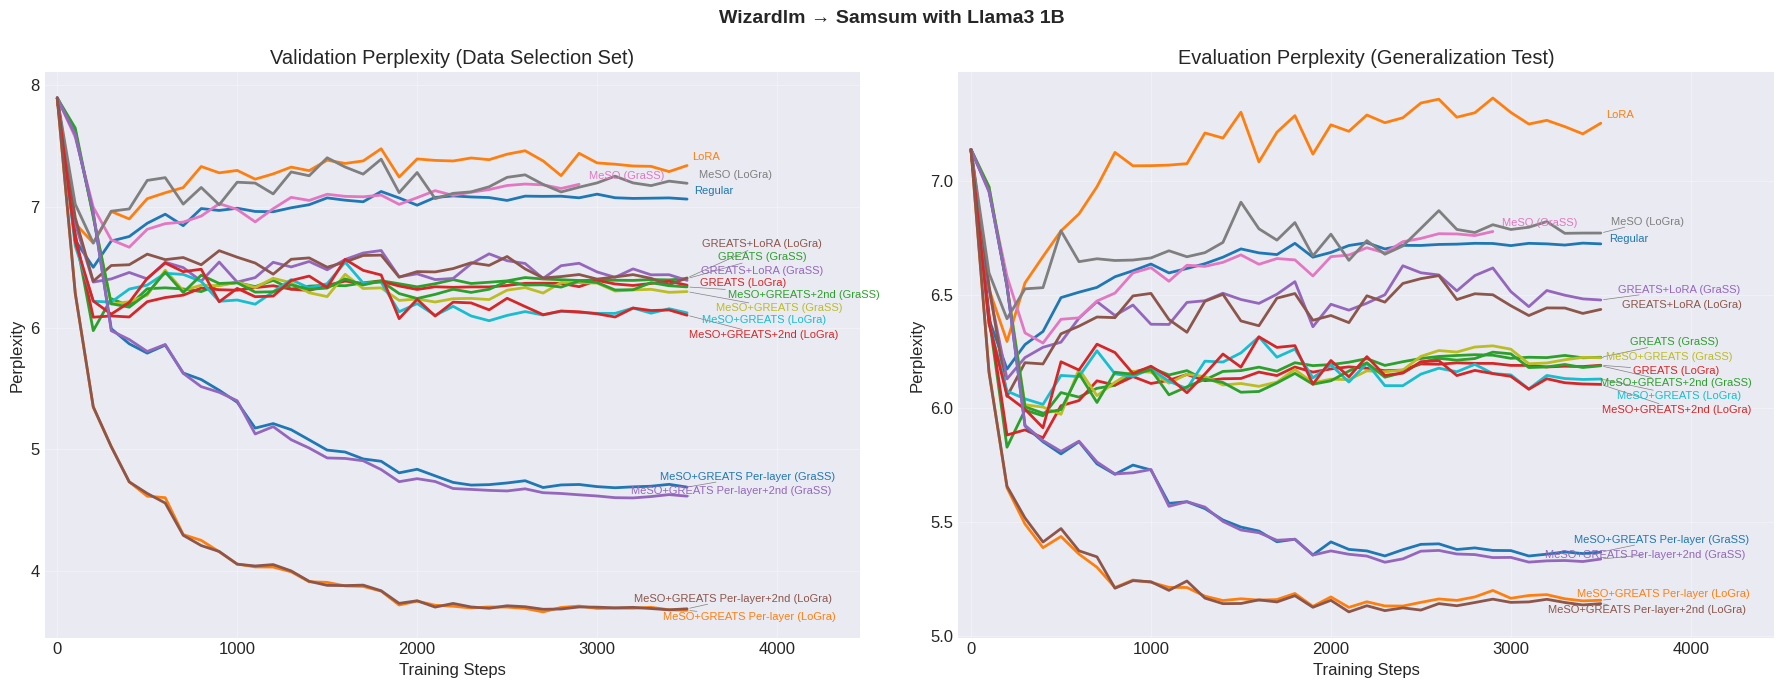

In [47]:
# Plotting configuration
max_steps = None  # Change to e.g., 100 to plot only first 100 steps
step_interval = None  # Change to e.g., 5 to plot every 5th step

# Build plot title based on train→task combination
train_name = train_dataset.replace('_', ' ').title()
task_name = task.upper() if task in ['tydiqa', 'mmlu', 'bbh', 'gsm8k'] else task.replace('_', ' ').title()
if subject:
    task_name = f"{task_name} ({subject.replace('_', ' ').title()})"
model_name = model.replace('_', ' ').replace('-', ' ').title()

plot_title = f"{train_name} → {task_name} with {model_name}"

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Add main title
fig.suptitle(plot_title, fontsize=14, fontweight='bold', y=0.98)

# Plot validation perplexity (small set for data selection)
ax = axes[0]
texts_val = []
for name, data in results.items():
    # Filter data by max_steps if specified
    if max_steps is not None:
        mask = data['steps'] <= max_steps
        steps = data['steps'][mask]
        val_perp = data['val_perplexity'][mask]
    else:
        steps = data['steps']
        val_perp = data['val_perplexity']

    # Sample every N-th step if step_interval is specified
    if step_interval is not None:
        indices = np.arange(0, len(steps), step_interval)
        steps = steps[indices]
        val_perp = val_perp[indices]

    line, = ax.plot(steps, val_perp, linewidth=2)
    # Collect text annotations for automatic adjustment
    texts_val.append(ax.text(steps[-1], val_perp[-1], name, fontsize=8, color=line.get_color()))

ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Validation Perplexity (Data Selection Set)')
ax.grid(True, alpha=0.3)
# Add right margin for annotations
ax.margins(x=0.02)
ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
# Adjust text positions to avoid overlaps
adjust_text(texts_val, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Plot evaluation perplexity (large held-out set)
ax = axes[1]
texts_eval = []
for name, data in results.items():
    # Filter data by max_steps if specified
    if max_steps is not None:
        mask = data['steps'] <= max_steps
        steps = data['steps'][mask]
        eval_perp = data['eval_perplexity'][mask]
    else:
        steps = data['steps']
        eval_perp = data['eval_perplexity']

    # Sample every N-th step if step_interval is specified
    if step_interval is not None:
        indices = np.arange(0, len(steps), step_interval)
        steps = steps[indices]
        eval_perp = eval_perp[indices]

    line, = ax.plot(steps, eval_perp, linewidth=2)
    # Collect text annotations for automatic adjustment
    texts_eval.append(ax.text(steps[-1], eval_perp[-1], name, fontsize=8, color=line.get_color()))

ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Evaluation Perplexity (Generalization Test)')
ax.grid(True, alpha=0.3)
# Add right margin for annotations
ax.margins(x=0.02)
ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
# Adjust text positions to avoid overlaps
adjust_text(texts_eval, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.tight_layout()
plt.show()

## Plot Perplexity vs. Wall Time (Compute-Time Trade-off)

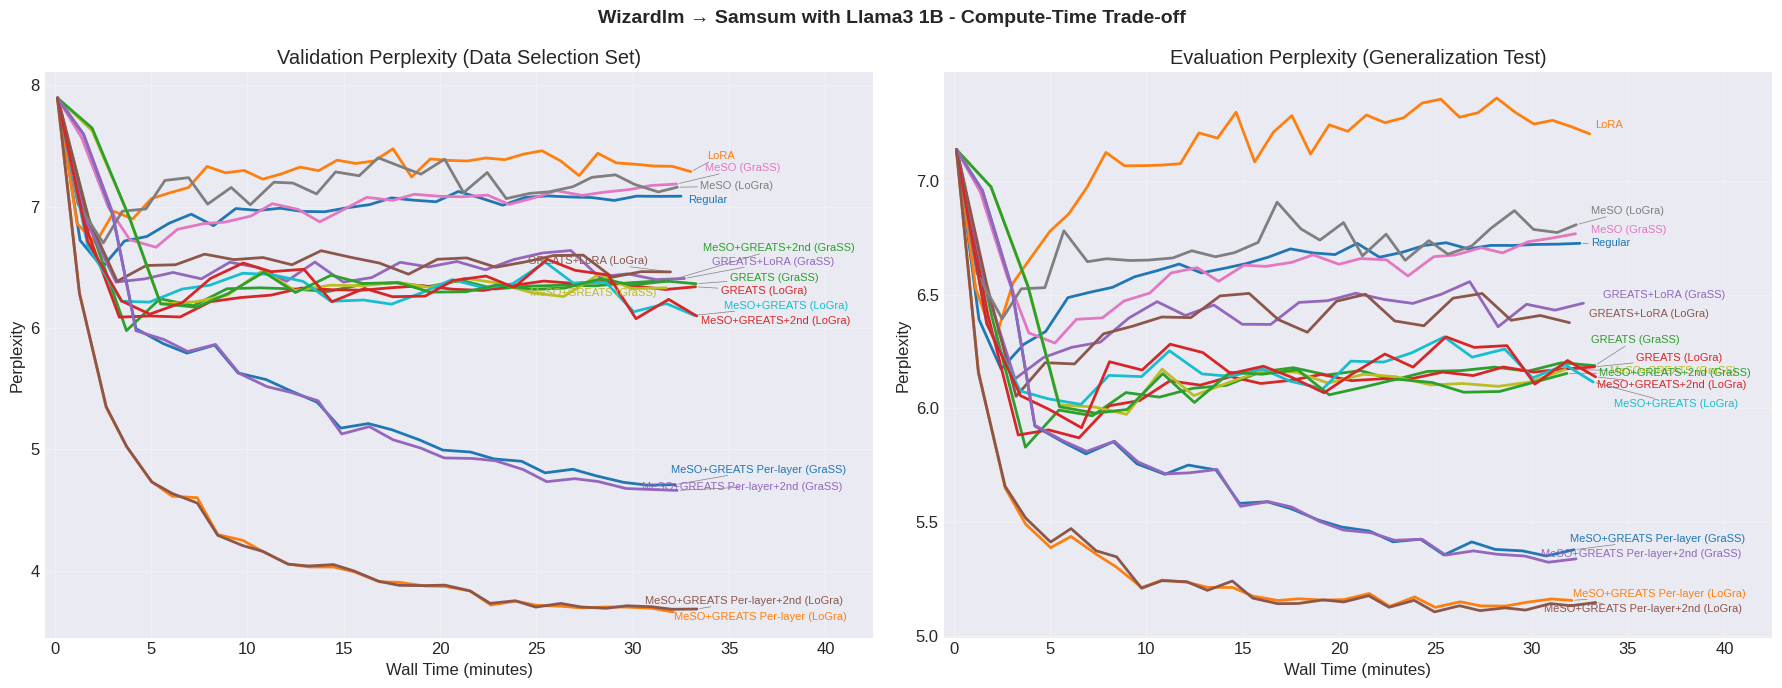

In [48]:
# Check if wall time data is available
has_wall_time = any(data['wall_time'] is not None for data in results.values())

if has_wall_time:
    # Plotting configuration
    max_wall_time = 2000  # Change to e.g., 3600 to plot only first hour (in seconds)

    # Build plot title
    plot_title_time = f"{train_name} → {task_name} with {model_name} - Compute-Time Trade-off"

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Add main title
    fig.suptitle(plot_title_time, fontsize=14, fontweight='bold', y=0.98)

    # Plot validation perplexity vs. wall time
    ax = axes[0]
    texts_val_time = []
    for name, data in results.items():
        if data['wall_time'] is not None:
            wall_time = data['wall_time']
            val_perp = data['val_perplexity']

            # Filter by max_wall_time if specified
            if max_wall_time is not None:
                mask = wall_time <= max_wall_time
                wall_time = wall_time[mask]
                val_perp = val_perp[mask]

            # Convert wall time to minutes for better readability
            wall_time_minutes = wall_time / 60.0
            line, = ax.plot(wall_time_minutes, val_perp, linewidth=2)
            # Collect text annotations for automatic adjustment
            texts_val_time.append(ax.text(wall_time_minutes[-1], val_perp[-1], name, fontsize=8, color=line.get_color()))

    ax.set_xlabel('Wall Time (minutes)')
    ax.set_ylabel('Perplexity')
    ax.set_title('Validation Perplexity (Data Selection Set)')
    ax.grid(True, alpha=0.3)
    # Add right margin for annotations
    ax.margins(x=0.02)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
    # Adjust text positions to avoid overlaps
    adjust_text(texts_val_time, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # Plot evaluation perplexity vs. wall time
    ax = axes[1]
    texts_eval_time = []
    for name, data in results.items():
        if data['wall_time'] is not None:
            wall_time = data['wall_time']
            eval_perp = data['eval_perplexity']

            # Filter by max_wall_time if specified
            if max_wall_time is not None:
                mask = wall_time <= max_wall_time
                wall_time = wall_time[mask]
                eval_perp = eval_perp[mask]

            # Convert wall time to minutes for better readability
            wall_time_minutes = wall_time / 60.0
            line, = ax.plot(wall_time_minutes, eval_perp, linewidth=2)
            # Collect text annotations for automatic adjustment
            texts_eval_time.append(ax.text(wall_time_minutes[-1], eval_perp[-1], name, fontsize=8, color=line.get_color()))

    ax.set_xlabel('Wall Time (minutes)')
    ax.set_ylabel('Perplexity')
    ax.set_title('Evaluation Perplexity (Generalization Test)')
    ax.grid(True, alpha=0.3)
    # Add right margin for annotations
    ax.margins(x=0.02)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
    # Adjust text positions to avoid overlaps
    adjust_text(texts_eval_time, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.tight_layout()
    plt.show()
else:
    print("Wall time data not available in the results.")
    print("Please re-run the training with the updated trainer to collect wall time data.")

## Compare Final Performance

In [6]:
# Print final results
print(f"\n{'='*80}")
print(f"Final Perplexity Results: {train_dataset} → {task}")
print(f"{'='*80}")
print(f"{'Method':<35} {'Val Perplexity':<18} {'Eval Perplexity':<18}")
print("-" * 80)

# Sort by eval perplexity for easier comparison
sorted_results = sorted(results.items(), key=lambda x: x[1]['eval_perplexity'][-1])

for name, data in sorted_results:
    final_val = data['val_perplexity'][-1]
    final_eval = data['eval_perplexity'][-1]
    print(f"{name:<35} {final_val:<18.4f} {final_eval:<18.4f}")

print("=" * 80)


Final Perplexity Results: alpaca → samsum
Method                              Val Perplexity     Eval Perplexity   
--------------------------------------------------------------------------------
MeSO+GREATS Per-layer+2nd (GraSS)   3.3358             5.0217            
MeSO+GREATS Per-layer (GraSS)       3.2962             5.0245            
MeSO+GREATS Per-layer (LoGra)       2.7544             5.0397            
MeSO+GREATS Per-layer+2nd (LoGra)   2.7842             5.0786            
MeSO+GREATS (LoGra)                 5.0680             5.3441            
GREATS+LoRA (GraSS)                 5.4537             5.3447            
GREATS+LoRA (LoGra)                 5.4949             5.3824            
MeSO+GREATS+2nd (LoGra)             5.0766             5.3843            
GREATS (GraSS)                      5.5933             5.4610            
MeSO+GREATS (GraSS)                 5.6122             5.5481            
MeSO+GREATS+2nd (GraSS)             5.5697             5.5487 

## Plot Improvement Over Baseline

In [7]:
def load_accuracy_results(result_path):
    """Load accuracy results from evaluation output files."""
    if not Path(result_path).exists():
        return None

    with open(result_path, 'r') as f:
        data = json.load(f)

    return data


def build_accuracy_path(train_dataset, task, method_name, result_type, config=None, subject=None):
    """Build the path for accuracy results using the same directory structure."""
    if method_name not in method_definitions:
        return None

    # Get method definition (now 6 elements)
    data_selection, optimizer, compression, training_type, selection_mode, use_second_order = method_definitions[method_name]

    # Use default config or provided config
    cfg = config or default_config
    batch_size = cfg['batch_size']
    percentage = cfg['percentage']
    n_val = cfg['n_val']
    seed = cfg['seed']
    lr = cfg['lr_lora'] if training_type == 'lora' else cfg['lr_full']

    # Build method string: data_selection-optimizer-compression[-per_layer][-2nd]
    method_str = f"{data_selection}-{optimizer}-{compression}"

    # Add '-per_layer' suffix for MeSO+GREATS with per-layer selection mode
    if optimizer == 'MeSO' and data_selection != 'NA' and selection_mode == 'per_layer':
        method_str = f"{method_str}-per_layer"

    # Add '-2nd' suffix for data selection with second-order interactions
    if data_selection != 'NA' and use_second_order:
        method_str = f"{method_str}-2nd"

    # Build setting string: model-job_type-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}
    setting_str = f"{model}-{training_type}-p{percentage}-lr{lr}-b{batch_size}-v{n_val}-s{seed}"

    # Build task string (with subject for MMLU/BBH)
    if task in ['mmlu', 'bbh'] and subject:
        task_str = f"{task}_{subject}"
    else:
        task_str = task

    # Full directory name
    dir_name = f"{train_dataset}_{task_str}-{method_str}-{setting_str}"

    return f"{out_dir}/{dir_name}/{result_type}_results.json"


# Determine result type based on task
if task == 'tydiqa':
    result_type = 'tydiqa'
elif task in ['mmlu', 'bbh']:
    result_type = 'mmlu'
elif task in ['gsm8k', 'math500']:
    result_type = 'math'
elif task == 'samsum':
    result_type = 'samsum'
else:
    result_type = task

# Build accuracy paths for FILTERED methods only
accuracy_experiments = {}
for method_name in filtered_methods.keys():
    path = build_accuracy_path(train_dataset, task, method_name, result_type, default_config, subject)
    if path:
        accuracy_experiments[method_name] = path

# Load all accuracy results
accuracy_results = {}
for name, path in accuracy_experiments.items():
    result = load_accuracy_results(path)
    if result is not None:
        accuracy_results[name] = result

# Print accuracy results
if accuracy_results:
    print(f"\n{'='*80}")
    print(f"Task-Specific Evaluation Results: {train_dataset} → {task}")
    print(f"{'='*80}")

    if task == 'tydiqa':
        print(f"{'Method':<35} {'F1 Score':<15} {'Exact Match':<15} {'N_test':<10}")
        print("-" * 80)

        for name, data in accuracy_results.items():
            f1 = data.get('f1_score', None)
            em = data.get('exact_match', None)
            n_test = data.get('n_test', 'N/A')

            f1_str = f"{f1:.2f}" if isinstance(f1, (int, float)) else str(f1) if f1 is not None else 'N/A'
            em_str = f"{em:.2f}" if isinstance(em, (int, float)) else str(em) if em is not None else 'N/A'

            print(f"{name:<35} {f1_str:<15} {em_str:<15} {n_test:<10}")

    elif task in ['mmlu', 'bbh']:
        print(f"{'Method':<35} {'Accuracy (%)':<15} {'Correct/Total':<20}")
        print("-" * 80)

        for name, data in accuracy_results.items():
            accuracy = data.get('accuracy', None)
            correct = data.get('num_correct', None)
            total = data.get('num_total', None)

            acc_str = f"{accuracy*100:.2f}" if isinstance(accuracy, (int, float)) else str(accuracy) if accuracy is not None else 'N/A'
            ct_str = f"{correct}/{total}" if correct is not None and total is not None else 'N/A'

            print(f"{name:<35} {acc_str:<15} {ct_str:<20}")

    elif task in ['gsm8k', 'math500']:
        print(f"{'Method':<35} {'Accuracy (%)':<15} {'Correct/Total':<20}")
        print("-" * 80)

        for name, data in accuracy_results.items():
            accuracy = data.get('accuracy', None)
            correct = data.get('num_correct', None)
            total = data.get('num_total', None)

            acc_str = f"{accuracy*100:.2f}" if isinstance(accuracy, (int, float)) else str(accuracy) if accuracy is not None else 'N/A'
            ct_str = f"{correct}/{total}" if correct is not None and total is not None else 'N/A'

            print(f"{name:<35} {acc_str:<15} {ct_str:<20}")

    elif task == 'samsum':
        print(f"{'Method':<35} {'ROUGE-1':<12} {'ROUGE-2':<12} {'ROUGE-L':<12}")
        print("-" * 80)

        for name, data in accuracy_results.items():
            rouge1 = data.get('rouge1', None)
            rouge2 = data.get('rouge2', None)
            rougeL = data.get('rougeL', None)

            r1_str = f"{rouge1:.2f}" if isinstance(rouge1, (int, float)) else 'N/A'
            r2_str = f"{rouge2:.2f}" if isinstance(rouge2, (int, float)) else 'N/A'
            rL_str = f"{rougeL:.2f}" if isinstance(rougeL, (int, float)) else 'N/A'

            print(f"{name:<35} {r1_str:<12} {r2_str:<12} {rL_str:<12}")
    else:
        # Generic output for unknown task types
        print("Results:")
        for name, data in accuracy_results.items():
            print(f"\n{name}:")
            for key, value in data.items():
                print(f"  {key}: {value}")

    print("=" * 80)
else:
    print(f"\nNo accuracy results found for {train_dataset} → {task}.")
    print("This is expected if evaluations haven't been run yet.")


No accuracy results found for alpaca → samsum.
This is expected if evaluations haven't been run yet.
